# Разработка модели машинного обучения для предсказания вероятности ДТП

**Описание проекта:**
На основании исторических данных о дорожно-транспортных происшествиях в одном из регионов необходимо разработать модель, способную оценивать риск ДТП по выбранному маршруту. Модель будет учитывать только случаи с участием автомобилей, приведшие к повреждениям (кроме царапин), и данные за 2012 год. Система позволит предупреждать водителей о повышенном уровне риска и предоставлять рекомендации по маршруту.

**Цель проекта:**
Разработать модель машинного обучения для предсказания вероятности ДТП, выявить ключевые факторы риска и оценить возможность создания системы оперативной оценки водительского риска при выдаче автомобиля.

**Ход исследования:**

* **Подготовка данных:** подключение к базе данных, загрузка и первичный анализ таблиц, проверка связей между ними.
* **Статистический анализ:** исследование факторов, влияющих на вероятность ДТП, визуализация распределений, выявление сезонных и ситуационных закономерностей.
* **Предварительная обработка:** фильтрация данных по условиям заказчика, обработка пропусков, корректировка типов данных, объединение таблиц.
* **Формирование признаков:** отбор и кодирование переменных, связанных с характеристиками участников, автомобилей, дорожных условий и обстоятельств ДТП.
* **Моделирование:** обучение нескольких моделей с подбором гиперпараметров, оценка по выбранной метрике, сравнение результатов.
* **Интерпретация результатов:** анализ важности признаков, исследование влияния ключевых факторов и формулировка рекомендаций по оборудованию автомобилей.

**Данные:**

* **collisions** — общая информация о ДТП (место, дата, время и обстоятельства).
* **parties** — сведения об участниках ДТП (тип участника, вина, состояние).
* **vehicles** — данные о пострадавших транспортных средствах (возраст, тип повреждений).

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import phik
import shap
import psycopg2

from sqlalchemy import create_engine 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import (OneHotEncoder,
                                   StandardScaler,
                                   OrdinalEncoder)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (confusion_matrix,
                             precision_score,
                             recall_score,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from scipy.stats import uniform

from src.sql.config import DB_CONFIG
import src.sql.sql_queries as sql_queries
import src.visualization as visual
from src.data_prepare import data_info

#Установка единого формата данных
pd.options.display.float_format = '{:,.3f}'.format
pd.options.mode.chained_assignment = None

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42


## Подключение к базе данных

Создадим строку для соединения с базой данных и передадим ее функции create_engine().

In [2]:
connection_string = (
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

engine = create_engine(connection_string) 


## Первичное исследование таблиц

Проверим наличие и выведем список существующих таблиц в схеме 'public'. 

In [4]:
pd.read_sql_query(sql_queries.GET_ALL_TABLES, con=engine)


,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


In [5]:
pd.read_sql_query(sql_queries.GET_CASE_IDS, con=engine)


,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021


В базе 4 таблицы. Таблицы collisions, parties и vehicles указаны в ТЗ и нужны по условию задачи. Также в данных есть дополнительная таблица case_ids, которая содержит уникальный id ДТП и год происшествия. Эту таблицу можно при необходимости использовать для фильтрации по году. 

Рассмотрим содержимое остальных таблиц.

In [6]:
pd.read_sql_query(sql_queries.GET_VEHICLES, con=engine)


,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5


Таблица `vehicles` содержит информацию о пострадавших машинах. Данные в таблице соответствуют имеющейся ER-диаграмме и их описанию. 

Ключи: поля `case_id`, `party_number`. Поле `case_id` неуникально, т.к. в одном ДТП может участвовать несколько машин, дополнительно неободимо учитывать `party_number` - номер участника происшествия.
Характеристики ТС: тип кузова, трансмиссия, возраст авто (`vehicle_age`) — обязательный для учёта фактор. 

In [7]:
pd.read_sql_query(sql_queries.GET_COLLISIONS, con=engine)


,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.000,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.000,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.000,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.000,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.000,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00


Таблица `collisions` описывает общую информацию о ДТП. Данные в таблице соответствуют имеющейся ER-диаграмме и их описанию. В описании данных нет информации о поле `control_device`. Вероятно, это характеристика наличия и состояния устройства регулирования движения на месте аварии, в таком случае значение None - нерегулируемый перекресток, отрезок дороги без знаков и т.п.

Ключ: поле `case_id` - уникальный идентификатор происшествия. Информация о происшествиях содержит: дату/время ДТП, условия дороги (road_surface, road_condition_1), освещённость (lighting), тип столкновения, регулирующие устройства  и пр. 

In [8]:
pd.read_sql_query(sql_queries.GET_PARTIES, con=engine)


,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.000,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.000,had not been drinking,None,0
2,29,3899462,2,car,0,21.000,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.000,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0


Таблица `parties` содержит информацию об участниках ДТП. Данные в таблице соответствуют имеющейся ER-диаграмме и их описанию. 

Ключи: поля `case_id`, `party_number`. Поле `case_id` неуникально, т.к. по аналогии с машинами, в ДТП может быть несколько участников. Описание сторон ДТП включают: тип участника (для модели будет использоваться только тип `car`), виновность (at_fault — целевая переменная), трезвость, признаки употребления лекарств/веществ, наличие телефона с громкой связью в автомобиле.

Оценим размер таблиц и количество уникальных ключей.

In [9]:
pd.read_sql_query(sql_queries.GET_TABLES_SHAPE, con=engine)


,table,rows,uniq_case
0,vehicles,1021234,792642
1,case_ids,1400000,1400000
2,collisions,1400000,1400000
3,parties,2752408,1400000


Таблица `collisions`: 1 400 000 строк и столько же уникальных case_id → поле case_id действительно является уникальным ключом. \
Таблица `parties`: 2 752 408 строк и 1 400 000 уникальных case_id → в среднем на одно ДТП приходится ~1,96 участников, что соответствует ожиданиям.\
Таблица `vehicles`: 1 021 234 строк и 792 642 уникальных case_id → в таблице содержится информация не обо всех ДТП, а, вероятно, только о тех, где пострадали транспортные средства (≈ 56% кейсов от общего числа).

Оценим диапазон дат ДТП, провери наличие целевого периода - 2012 год.

In [10]:
pd.read_sql_query(sql_queries.GET_DATES, con=engine)


,min_date,max_date
0,2009-01-01,2020-07-26


Даты ДТП охватывают период с 01.01.2009 по 26.07.2020.

<b>Вывод по разделу "Первичное исследование таблиц"</b>

В базе присутствуют 3 таблицы (collisions, parties, vehicles), описанные в условии задачи и доп.таблица (сase_ids) c указанием года ДТП. Данные в таблице соответствуют имеющейся ER-диаграмме и их описанию. 
 
Проверка уникальных ключей показала: \
case_id в collisions уникален — можно использовать как первичный ключ. \
parties и vehicles имеют составной ключ case_id + party_number, согласно описанию. \
Таблицы согласованы по case_id, но vehicles покрывает не все кейсы — только ДТП с пострадавшими автомобилями.

Диапазон дат с 2009 по 2020 гг. позволит выбрать 2012 год как «срез» для моделирования.

##  Cтатистический анализ факторов ДТП

Проанализируем количество аварий по месяцам за весь период наблюдений. Подготовим sql-запрос для выгрузки нужной информации.

In [11]:
сollisions_per_month = pd.read_sql_query(sql_queries.GET_COLLISIONS_PER_MONTH, con=engine)
сollisions_per_month


,month,qty_collisions
0,1,132044
1,2,128858
2,3,139581
3,4,130180
4,5,130316
5,6,102594
6,7,102227
7,8,104089
8,9,105159
9,10,112237


Анализ данных за весь период наблюдений (с 01.01.2009 по 01.07.2020) показал выраженную сезонность в распределении ДТП по месяцам года. Максимальное количество аварий фиксируется в марте (139 581 случаев, 10,0% от всех), январь (132 044 - 9,4%) и май (130 316 - 9,3%). Минимальные значения наблюдаются в июле (102 227 - 7,3%), июне (102 594 - 7,3%) и августе (104 089 - 7,4%).

Построим график для визуализации результатов.

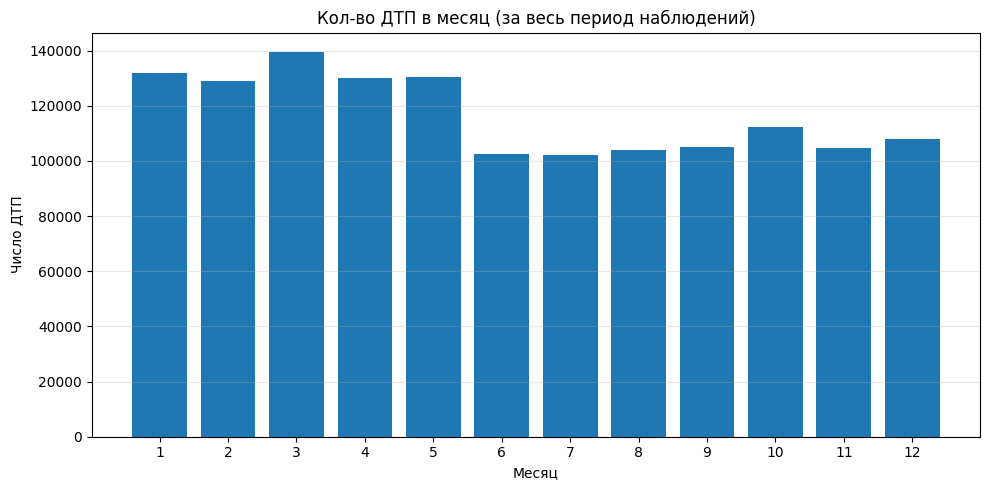

In [12]:
visual.bar_plot(сollisions_per_month,
         'month',
         'qty_collisions',
         title='Кол-во ДТП в месяц (за весь период наблюдений)',
         xlabel='Месяц',
         ylabel='Число ДТП',
         xticks=range(1,13))  


На графике четко прослеживается зимне-весенний пик по количеству ДТП (январь–май) и летнее снижение (июнь–август).

Резкий спад с мая на июнь (~ 20–25 тыс. ДТП) выглядит устойчивым и, вероятно, связан с каникулами, отпускным сезоном и, возможно, изменением интенсивности трафика. Осенью (сентябрь–октябрь) наблюдается небольшой подъём после летнего минимума, но он не достигает зимне-весенних значений. Декабрь не входит в топ-3, но по уровню близок к осенним месяцам, что может объясняться как погодными условиями, так и предпраздничным сезоном.

Сформулируем задачи для дальнейшего анализа различных факторов ДТП:

1. **Анализ распределения типов ДТП по времени суток** \
   Определите, в какое время суток (`collision_time`) чаще происходят различные типы столкновений (`type_of_collision`) и как это связано с условиями освещения (`lighting`).

2. **Влияние возраста автомобиля на вероятность вины в ДТП** \
   Исследуйте зависимость между `vehicle_age` (таблица `vehicles`) и полем `at_fault` (таблица `parties`) для случаев с типом участника `car`.

3. **Топ-10 нарушений, приведших к ДТП** \
   Определите самые частые значения `pcf_violation_category` и их долю от всех ДТП.

4. **Распределение ДТП по дням недели и сезонам** \
   Найдите, в какие дни недели и сезоны года происходит больше всего аварий(таблица `collisions`).

5. **Роль типа коробки передач в аварийности** \
   Проверьте, отличается ли частота вины в ДТП (`at_fault`) в зависимости от `vehicle_transmission` (механическая/автоматическая).

6. **Географическое распределение аварий** \
    Постройте рейтинг районов (`county_location`) по числу ДТП и выявите районы с наибольшей концентрацией происшествий.
    
7. **Роль типа кузова в характере повреждений при ДТП** \
   Провериьте, отличается ли распределение серьёзности повреждений (`collision_damage`) в зависимости от типа кузова (`vehicle_type`).

Для анализа возьмем задачу из п.2. **Влияние возраста автомобиля на вероятность вины в ДТП**. \
Проанализируем как кизменяется доля виновников в аварии в зависимости от возраста авто. 

Порядок решения:
1. Объединим таблицы `vehicles` и `parties` по полям `case_id` и `party_number`. Оставим только строки где party_type ='car', и возьмем только автомобили с указанным возрастом. 
2. Для каждого возраста посчитаем количество происшествий и количество виновников ДТП. 
3. Рассчитаем на основании полученных данных долю виновников ДИП по каждому возрасту авто. 
4. Визуализируем данные.

In [13]:
age_fault = pd.read_sql_query(sql_queries.GET_AGE_FAULT, con=engine)
age_fault


,vehicle_age,qty_collisions,qty_faults,fault_rate
0,0,37077,16569,44.690
1,1,34525,14481,41.940
2,2,90442,50252,55.560
3,3,165138,91666,55.510
4,4,115622,52717,45.590
5,5,96702,38172,39.470
6,6,77012,28039,36.410
7,7,75985,27021,35.560
8,8,69055,24341,35.250
9,9,52373,18765,35.830


Для категории авто возрастом 16+ лет объём данных крайне мал — всего 134 автомобиля, что не позволяет надёжно оценить закономерности в этой группе. При малом объеме данных значение случайных факторов сильно возрастает. Исключим эти данные при построение графика.

Также есть 15 автомобилей возрастом - 161 год. Это явная аномалия, автомобилей с таким возрастом быть не может. Т.к. кол-во таких записей незначительно по сравнению с общим объемом ген.совокупности, их лучше удалить при подготовки данных для модели, если они попадут в выборку по целевому периоду.

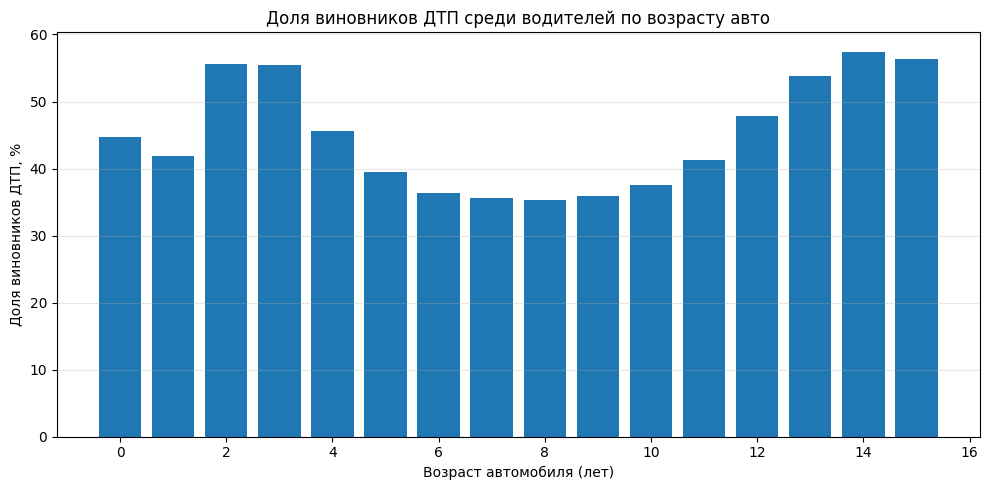

In [14]:
visual.bar_plot(age_fault.query('vehicle_age <= 15'),
         'vehicle_age',
         'fault_rate',
         title='Доля виновников ДТП среди водителей по возрасту авто',
         xlabel='Возраст автомобиля (лет)',
         ylabel='Доля виновников ДТП, %')  


Доля виновников среди водителей снижается от максимума у машин 2-3 лет (55%) до минимума у авто 7-9 лет (35%). Затем наблюдается рост — у машин 11–14 лет доля виновников увеличивается вплоть до максимума (57%) у 14-летних авто, что очень близко к категории 2-3 года. 

Новые авто часто приобретают менее опытные водители, доля виновников ДТП среди обладателей авто до 2-х не так велика, как среди 2-3 летних авто. Возможно, к этому времени у неопытных водителей наступает эффект «психологической уверенности» в техническом состоянии машины, что приводит к более рискованному поведению. Владельцы авто среднего возраста (6–10 лет) могут сочетать достаточный опыт и более спокойный стиль вождения с приемлемым техническим состоянием автомобиля, что приводит к снижению долю виновников ДТП. Старые авто (10+ лет) чаще имеют технические недостатки (износ тормозов, подвески, шин), могут быть менее безопасны конструктивно и эксплуатироваться в более агрессивных условиях, что приводит к повторному росту доли виновников.

Следующую задачу для анализа возьмем из п.5. **Роль типа коробки передач в аварийности** \
Проверим, отличается ли частота вины в ДТП (`at_fault`) в зависимости от `vehicle_transmission` (механическая/автоматическая). 

Порядок решения:
1. Объединим таблицы `vehicles` и `parties` по полям `case_id` и `party_number`. Оставим только строки где party_type ='car', и возьмем только автомобили с указанным типом трансмиссии. 
2. Для каждого типа посчитаем количество происшествий и количество виновников ДТП. 
3. Рассчитаем на основании полученных данных долю виновников ДИП по каждому возрасту авто. 
4. Визуализируем данные.

In [15]:
transmission_fault = pd.read_sql_query(sql_queries.GET_TRANSMISSION_FAULT, con=engine)
transmission_fault


,vehicle_transmission,qty_collisions,qty_faults,fault_rate
0,auto,471346,192472,40.830
1,manual,432960,208920,48.250


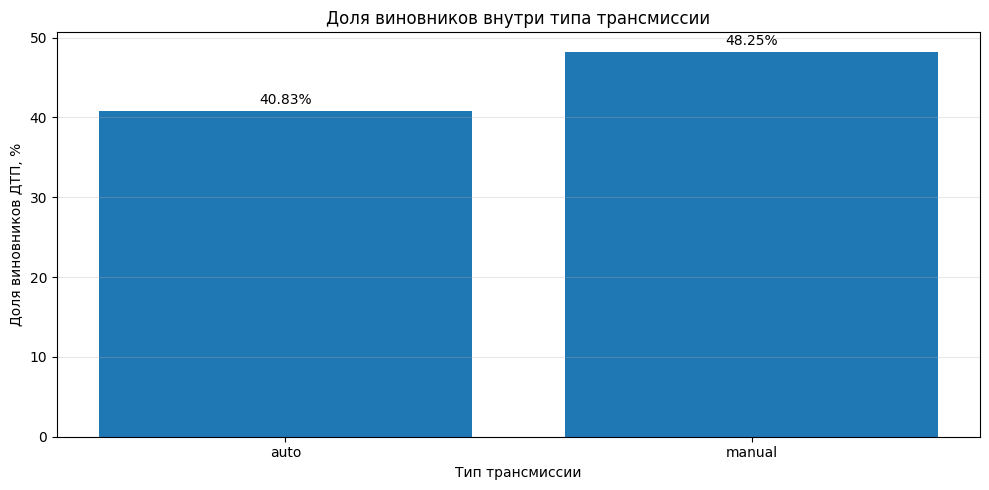

In [16]:
visual.bar_plot(transmission_fault,
         'vehicle_transmission',
         'fault_rate',
         title='Доля виновников внутри типа трансмиссии',
         xlabel='Тип трансмиссии',
         ylabel='Доля виновников ДТП, %',
         annotate=True)  


Анализ зависимости доли виновников ДТП от типа трансмиссии показал:
* Для автомобилей с **механической коробкой передач** доля виновников составляет **48.25%**,
* Для автомобилей с **автоматической коробкой передач** — **40.83%**.

Таким образом, владельцы машин с автоматической трансмиссией в среднем реже признаются виновниками ДТП, чем владельцы автомобилей с «механикой».

Возможно, это связано с тем, что автомобили с автоматической коробкой чаще выбирают водители с более спокойным стилем вождения (городские условия, меньше манёвров, связанных с переключением передач). На «механике» чаще ездят более опытные, к тому же доля «механики» выше среди более старых автомобилей, которые могут быть в худшем техническом состоянии.

Для более точной интерпретации полезно дополнительно можно учесть возраст автомобиля, пробег и характер поездок.

<b>Вывод по разделу "Статистический анализ факторов ДТП"</b>

Первичный анализ данных о ДТП выявил чёткие сезонные колебания аварийности: зимне-весенний пик (январь–май), летнее снижение (июнь–август) и умеренный рост осенью. Резкий спад с мая на июнь, вероятно, связан с каникулами, отпускным сезоном и снижением трафика, а зимне-весенний максимум — с неблагоприятными погодными условиями и повышенной транспортной активностью.

Изучение факторов, связанных с участниками ДТП, показало:

* **Возраст автомобиля** имеет U-образную зависимость с долей виновников: пик у авто 2–3 лет (\~55%), минимум у машин 7–9 лет (\~35%) и последующий рост у старых автомобилей (10+ лет). Это может отражать сочетание влияния опыта водителя, технического состояния автомобиля и особенностей эксплуатации.
* **Тип трансмиссии** также связан с аварийностью: автомобили с механической коробкой передач имеют более высокую долю виновников (48.25%) по сравнению с автоматическими (40.83%). Возможные объяснения — разница в стиле вождения и возрасте машин.

## Создание модели для оценки водительского риска

Подготовим данные для модели с учетом фильтрации выборки по усовиям заказчика:
- тип виновника — только машина (car): `party_type` ='car'
- ДТП привело к любым значимым повреждениям автомобиля любого из участников (все, кроме SCRATCH): `collision_damage` != 'scratch'
- данные за 2012 год: `collision_date` = 2012.

Чтобы оптимизировать запрос и снизить нагрузку на базу данных, проведем первичный отбор данных: выберем колонки, которые могут оказывать влиять на вероятность ДТП.

Часть переменных мы можем получить только **после свершения ДТП**, т.е. на момент оценки риска эти данные недоступны: `primary_collision_factor`, `type_of_collision`, `collision_damage`, `motor_vehicle_involved_with`, `intersection`. 

У нас нет данных о том, что автомобили оборудованы алкотестером, следовательно, мы не можем оценить употреблял ли человек алкоголь и его физическое состояние в целом, поэтому мы также не можем использовать колонки:  `party_sobriety` и `party_drug_physical`.

Мы хотим предсказать риск до поездки (после бронирования и выбора маршрута), значит эти признаки в момент предсказания неизвестны и включать в обучающие мы их не будем. Проведем отбор среди оставшихся признаков.

Итого первоначально используем следующие переменные:

### ТАБЛИЦА COLLISIONS
| Переменная | Описание |
|------------|----------|
| weather_1 | Погода во время ДТП — влияет на сцепление и видимость. |
| road_surface | Тип покрытия (асфальт, гравий и т.д.) — разное сцепление, опасность заноса. |
| road_condition_1 | Состояние дороги (ремонт) — прямой фактор риска. |
| lighting | Освещенность — влияет на видимость, особенно ночью. |
| distance | Расстояние от главной дороги, м - интенсивность трафика может влиять на риск ДТП. |

### ТАБЛИЦА PARTIES
| Переменная | Описание |
|------------|----------|
| cellphone_in_use | Наличие телефона с громкой связью в авто — отвлечение водителя. |
| at_fault | Целевая переменная. |

### ТАБЛИЦА VEHICLES
| Переменная | Описание |
|------------|----------|
| vehicle_type | Тип кузова — влияет на маневренность и зону обзора. |
| vehicle_transmission | Тип коробки — косвенно отражает опыт и стиль вождения. |
| vehicle_age | Возраст авто — связан с техническим состоянием и безопасностью. |

In [17]:
data = pd.read_sql_query(sql_queries.GET_FINAL_DATA, con=engine)
print('Размер выборки:', data.shape)
data.head(2)


Размер выборки: (56248, 10)


,weather_1,road_surface,road_condition_1,lighting,distance,cellphone_in_use,at_fault,vehicle_type,vehicle_transmission,vehicle_age
0,clear,dry,normal,daylight,20.000,0.000,0,sedan,auto,2.000
1,clear,dry,other,dark with no street lights,40.000,0.000,1,sedan,auto,5.000


Посмотрим общую информацию по данным.

In [20]:
data_info(data)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 56248 строк × 10 столбцов


,weather_1,road_surface,road_condition_1,lighting,distance,cellphone_in_use,at_fault,vehicle_type,vehicle_transmission,vehicle_age
0,clear,dry,normal,daylight,20.000,0.000,0,sedan,auto,2.000
1,clear,dry,other,dark with no street lights,40.000,0.000,1,sedan,auto,5.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   weather_1             56080 non-null  object 
 1   road_surface          55900 non-null  object 
 2   road_condition_1      55999 non-null  object 
 3   lighting              56094 non-null  object 
 4   distance              56248 non-null  float64
 5   cellphone_in_use      51777 non-null  float64
 6   at_fault              56248 non-null  int64  
 7   vehicle_type          56248 non-null  object 
 8   vehicle_transmission  55389 non-null  object 
 9   vehicle_age           54554 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 4.3+ MB


,count,mean,std,min,25%,50%,75%,max
distance,"56,248.000",859.439,"7,240.295",0.000,7.000,135.000,545.000,"1,584,000.000"
cellphone_in_use,"51,777.000",0.020,0.141,0.000,0.000,0.000,0.000,1.000
at_fault,"56,248.000",0.504,0.500,0.000,0.000,1.000,1.000,1.000
vehicle_age,"54,554.000",4.856,3.235,0.000,3.000,4.000,7.000,161.000


Пропущенные значения:
Столбцы с пропусками:
cellphone_in_use: 4,471 (7.95%)
vehicle_age: 1,694 (3.01%)
vehicle_transmission: 859 (1.53%)
road_surface: 348 (0.62%)
road_condition_1: 249 (0.44%)
weather_1: 168 (0.30%)
lighting: 154 (0.27%)
Наличие дубликатов:
Найдено дубликатов: 24,725 (43.96%)


В исxодных таблицах были множественные записи по одному ДТП, поэтому при исключении многочисленных id появилось большое количество дубликатов. При этом полностью идентичные строки не несут ценности для модели, т.к. не добавляют новой информации. Удалим такие строки.

In [ ]:
print('Общий размер выборки:', data.shape)
data = data.drop_duplicates()
print('Размер выборки после удаления дубликатов:', data.shape)


Общий размер выборки: (56248, 10)
Размер выборки после удаления дубликатов: (31523, 10)


Переименуем колонки `road_condition_1` и `weather_1`, удалим неинформативную "_1".

In [23]:
data = data.rename(columns=
                          {'road_condition_1':'road_condition',
                          'weather_1':'weather'})


**Категориальные признаки**

Большинство отобранных признаков являются категориальными. Полe `cellphone_in_use` - бинарный признак, который также по своей сути является категориальными. Приведем его к типу str.

In [24]:
data['cellphone_in_use'] = data['cellphone_in_use'].astype(str)


Проверим категориальные переменные на наличие неявных дубликатов.

In [25]:
cat_cols = data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'Уникальные значения в поле {col}:', data[col].unique())
    print('Количество уникальных значений', len(data[col].unique()))
    print('___________________________')


Уникальные значения в поле weather: ['clear' 'cloudy' 'fog' None 'raining' 'snowing' 'other' 'wind']
Количество уникальных значений 8
___________________________
Уникальные значения в поле road_surface: ['dry' 'wet' None 'snowy' 'slippery']
Количество уникальных значений 5
___________________________
Уникальные значения в поле road_condition: ['normal' 'other' None 'construction' 'obstruction' 'reduced width'
 'holes' 'loose material' 'flooded']
Количество уникальных значений 9
___________________________
Уникальные значения в поле lighting: ['daylight' 'dark with no street lights' 'dark with street lights'
 'dusk or dawn' None 'dark with street lights not functioning']
Количество уникальных значений 6
___________________________
Уникальные значения в поле cellphone_in_use: ['0.0' 'nan' '1.0']
Количество уникальных значений 3
___________________________
Уникальные значения в поле vehicle_type: ['sedan' 'coupe' 'other']
Количество уникальных значений 3
___________________________
Уникал

Неявных дубликатов в значениях невыявлено. Количество уникальных значений в полях в основном небольшое и позволяет оставить их без укрупнения. 

Для категориальных переменных восстановить логически пропущенные значения затруднительно. Заменим пропуски также на значение "UNKNOWN".

In [26]:
for col in cat_cols:
    data[col] = data[col].fillna('UNKNOWN')
    data[col] = data[col].replace('nan', 'UNKNOWN')


In [29]:
cat_cols += ['at_fault']


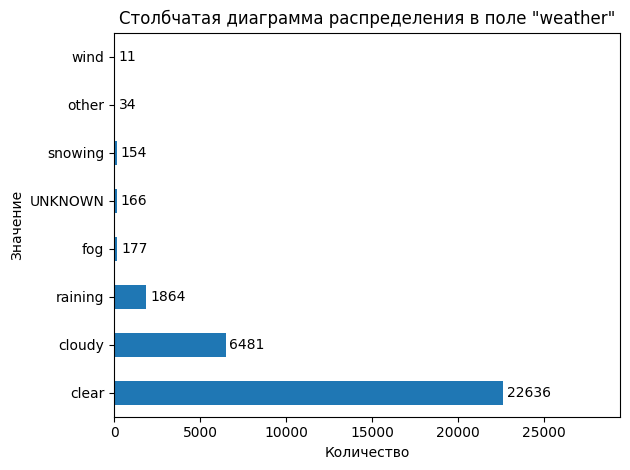

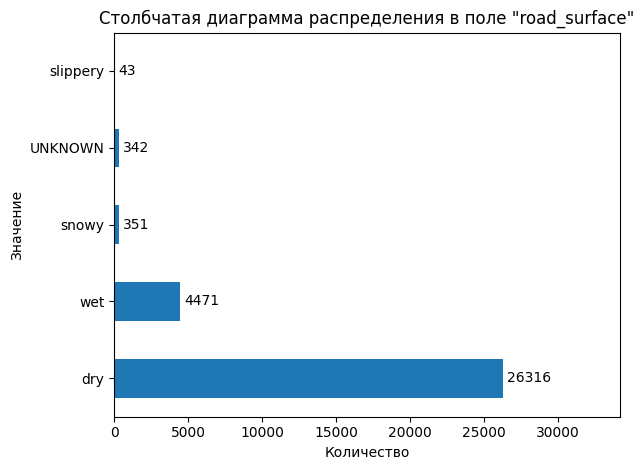

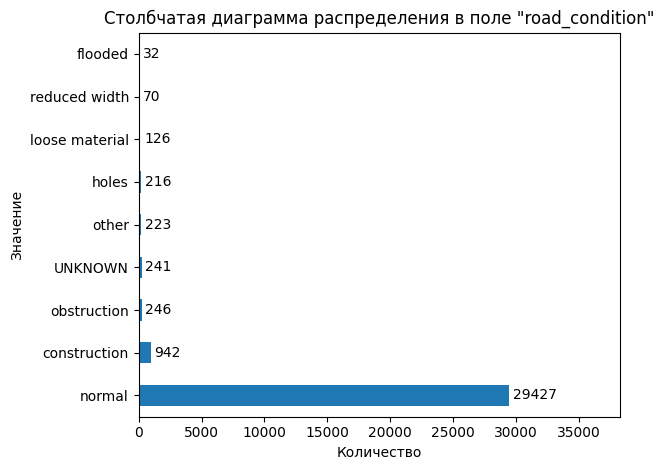

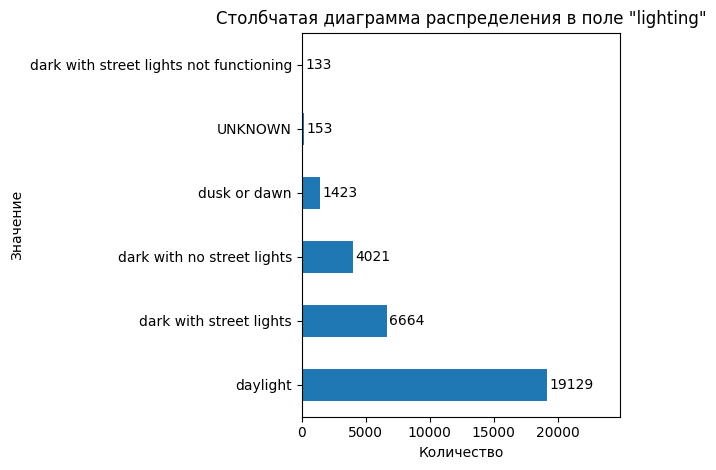

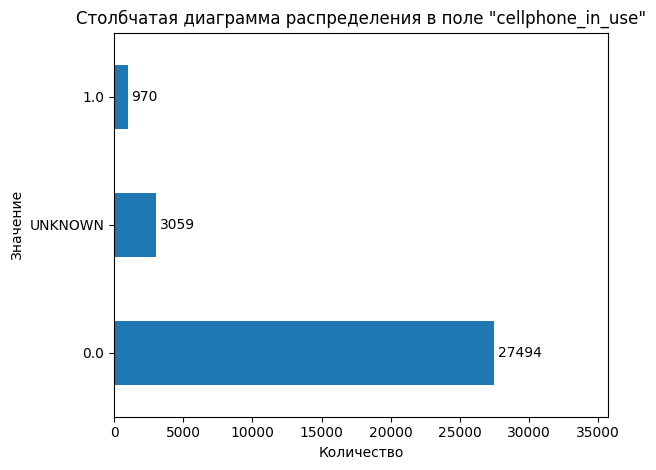

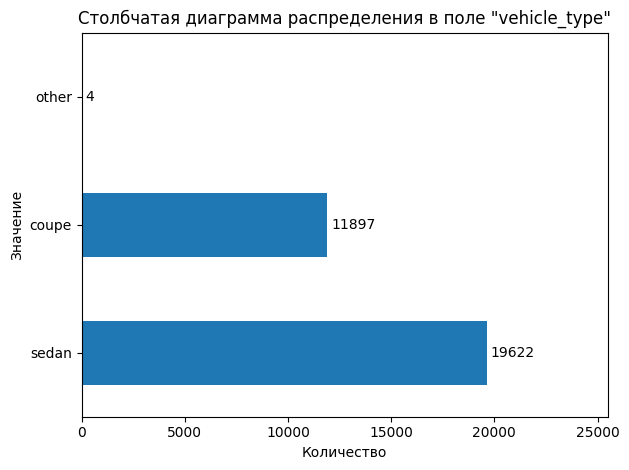

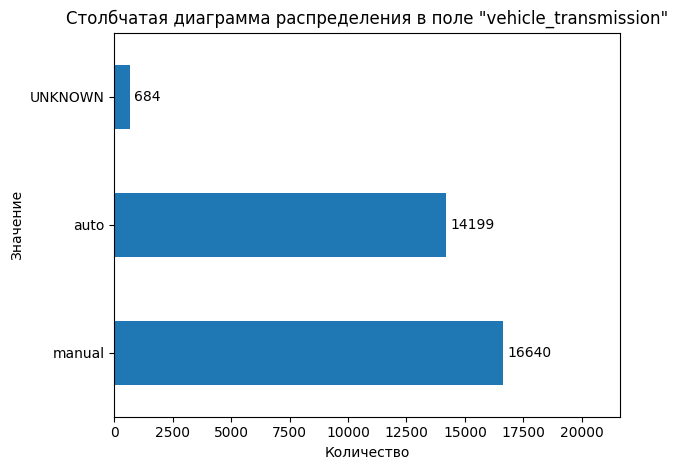

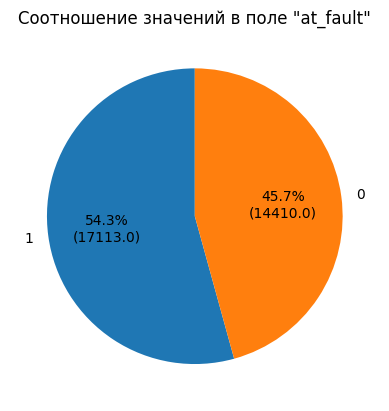

In [31]:
visual.category_graph(data, cat_cols)


**Погодные условия:** Чаще всего ясно (72%) или облачно (21%). Осадки и другие неблагоприятные условия встречаются редко. \
**Покрытие дороги:** В большинстве случаев поверхность дороги сухая (около 83%), реже мокрая (14%), крайне редко — снег или скользкая поверхность. \
**Состояние дороги:** В 93% состояние дороги нормальное, без ярко-выраженных ям или иных дефектов полотна. \
**Освещение:** 60% ДТП происходят днём. Значимая часть — в тёмное время суток при работающем уличном освещении (21%) или без него (13%). \
**Использование телефона:** В подавляющем большинстве случаев (87%) зафиксировано, что телефона с громкой связью в авто не было. \
**Тип автомобиля:** Преобладают седаны (62%) и купе (38%), прочие типы единичны.\
**Трансмиссия:** Примерно поровну авто с автоматом (46%) и механикой (53%), небольшой процент — неизвестно.

Исходя из этого можно сформировать "портрет" наиболее типичной поездки, попавшей в выборку: автомобиль седан без возможности громкой связи на телефоне, на механической коробке передач. Сухая и ровная дорога. Ясная погода. Поездка совершается в дневное время.

Целевая переменная `at_fault` достаточно сбалансирована: 54% виновников и 46% невиновных. Применение дополнительных атрибутов типа 'class_weight' не потребуется. 

**Количественные переменные**

Среднее значение (1158) в поле `distance` сильно смещено относительно медианы (217). Скорее всего это связано с выбросами. Максимальное значение в выборке 1584000м выглядит нереалистичным. Посмотрим на распределение значений в этой переменной.

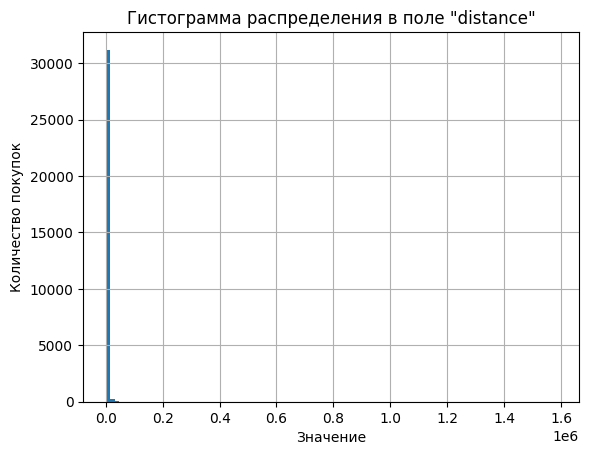

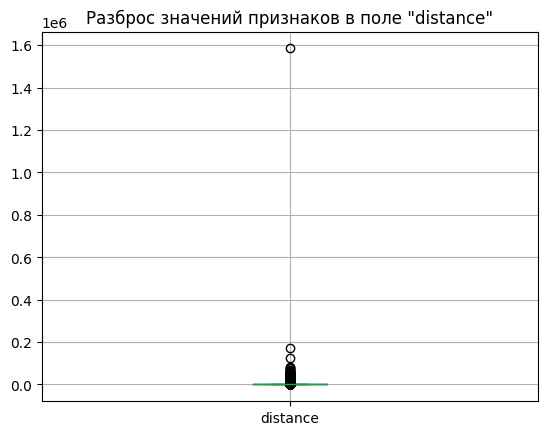

In [32]:
visual.numeric_graph(data, ['distance'])


На графике хорошо видно, что основная масса значений лежит в пределах сотен метров. Учитывая, что по условиям задачи мы рассматриваем данные одного из регионов, растояния в тысячи и даже миллионы метров от главной дороги - это явные аномалии. Рассчитаем кол-во наблюдений выходящих за пределы 99,5-го перцентиля.

In [33]:
percentile = data['distance'].quantile(0.995)
print('99,5-й перцентиль поля "distance":', percentile)

print('Кол-во значений выше 99,5-го перцентиля:', data.query('distance > @percentile')['distance'].count())
print(f"Доля значений выше 99,5-го перцентиля: {100*data[data['distance'] > percentile]['distance'].count()/data.shape[0]:.2f}")


99,5-й перцентиль поля "distance": 21648.0
Кол-во значений выше 99,5-го перцентиля: 156
Доля значений выше 99,5-го перцентиля: 0.49


99.5-й перцентиль = 21 648м, выше этого значения всего 156 наблюдений (0.49% выборки). Значения до 20 км выглядят реалистичными (это могут быть расстояния от крупных магистралей или междугородние отрезки). Наблюдения выше 21 км (~0.5% выборки) выглядят как выбросы или ошибки ввода (вряд ли ДТП фиксируется на расстоянии в сотни километров от дороги). Удалим выбросы выше 99.5-го перцентиля из тренировочной выборки **после разделения данных** (чтобы модель была оценена на обычных данных, а не очень чистых), т.к. потеря <0.5% данных статистически несущественна. 

Максимальный возраст авто - 161 год. Аномальные значения, обнаруженные в предыдущем разделе попали в нашу выборку. Посмотрим сколько таких значений и в случае наличия удалим их позже из тренировочных данных.

In [34]:
print('Кол-во аномальных значений в поле vehicle_age:', data[data['vehicle_age'] > 20]['vehicle_age'].count())


Кол-во аномальных значений в поле vehicle_age: 2


Т.к. распределение возраста авто все еще ассимитрично вправо, медиана лучше отражает "типичный" возраст авто, поэтому для **заполнения пропусков используем медиану**. Чтобы избежать утечки данных, заполним пропуски **после разделения данных**: рассчитаем медиану на обучающей выборке и заполним ей обе выборки. Для заполнения можно включить в пайплайн предобработки SimpleImputer(strategy="median").

Изучим взамосвязь между признаками и рассчитаем коэффициенты корреляции. Т.к. у нас в данных большинство признаков - категориальные, используем коэффициент корреляции Фи. В параметр `interval_cols` передадим непрерывные признаки, в нашем случае это поле `distance`. Для наглядности построим тепловую карту.

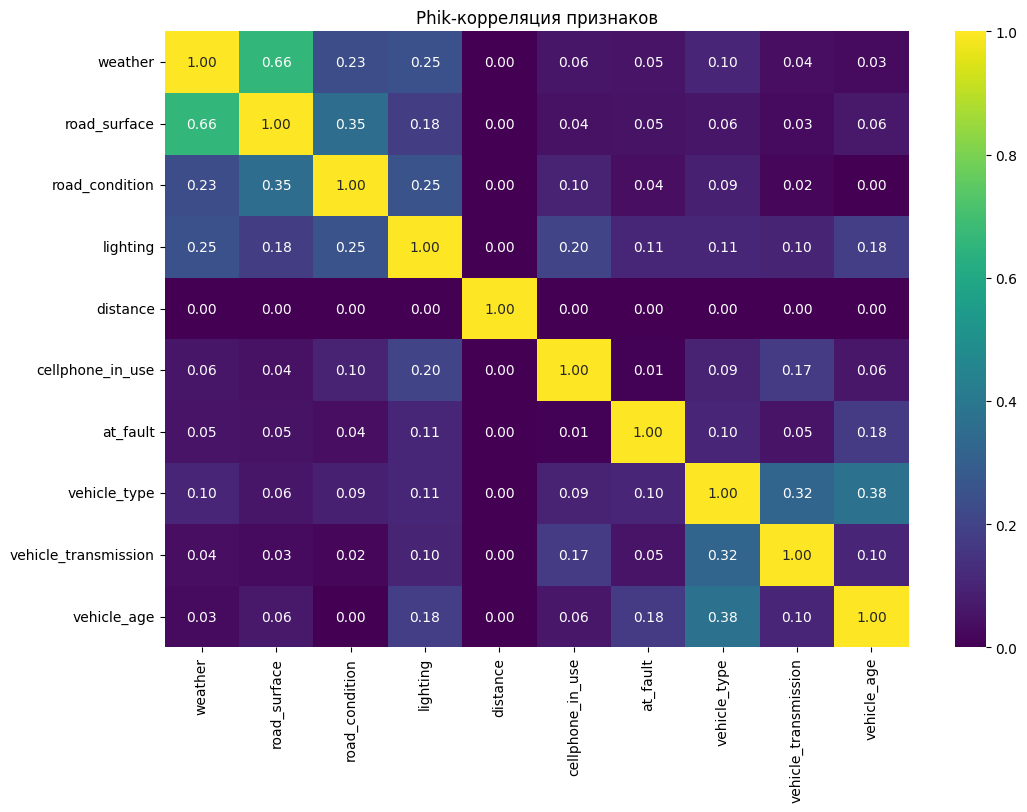

In [35]:
phik_matrix = data.phik_matrix(interval_cols=['distance'])

plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='viridis')
plt.title('Phik-корреляция признаков')
plt.show()


В данных нет мультиколлинеарных признаков - коэффициент корреляции <0.7, можно оставлять все признаки.
Наиболее связана между собой пара:  weather–road_surface (0.66) - при дожде/снеге поверхность дороги соответствует осадкам.

Целевая переменная слабо коррелирует с отдельными факторами, что говорит о сложной природе ДТП и необходимости многомерного анализа. Оставим для модели все отобранные признаки.

Разобьем данные на обучающую и тестовую выборку.

In [36]:
X = data.drop(columns=['at_fault'], axis=1)
y = data.at_fault


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE
)


In [38]:
print('Размер тренировочной выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)


Размер тренировочной выборки: (23642, 9)
Размер тестовой выборки: (7881, 9)


Удалим ранее обнаруженные выбросы из тренирововчной выборки.

In [39]:
mask = (X_train['vehicle_age'] != 161) & (X_train['distance'] <= percentile)

X_train = X_train.loc[mask].copy()
y_train = y_train.loc[mask].copy()

print('Размер тренировочной выборки после удаления выбросов:', X_train.shape)
print('Кол-во целевых переменных:', len(y_train))


Размер тренировочной выборки после удаления выбросов: (23514, 9)
Кол-во целевых переменных: 23514


Переходим к подготовке пайплайна для предобработки признаков. Подготовим списки с названиями признаков, разделенные по предполагаемому методу обработки. 

Бинарные и категориальные признаки закодируем с помощью one-hot(OHE). Т.к. упорядоченность признаков в нашем случае довольно субъективная: например, кому-то может быть проще ездить в туман, но категорически сложно в гололёд и тд, то объективно-упорядоченных признаков тут нет и принудительно задавать порядок разбиения не будем.

Количественные признаки - дистанция и возраст имеют различные диапазоны значений, поэтому применим к данным масштабирование с помощью метода StandartScaler. 

In [ ]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.columns.difference(num_cols)

print('Количественные признаки:', num_cols)
print('Категориальные признаки:', cat_cols)


Количественные признаки: ['distance', 'vehicle_age']
Категориальные признаки: Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface',
       'vehicle_transmission', 'vehicle_type', 'weather'],
      dtype='object')


Для `OrdinalEncoder` настроим на бесперебойную работу при появлении в новых данных ранее неизвестных значений признаков: установим параметр `handle_unknown='use_encoded_value'`, чтобы новые, ранее неизвестные значения кодировались константным значением, которое укажем в параметре `unknown_value`.

In [82]:
ord_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value= -1))
])


У `OneHotEncoder` настроим параметр `drop='first'`, чтобы в трансформированной матрице не было мультиколлинеарности и чтобы не попасть в дамми-ловушку.

In [83]:
ohe_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])


In [84]:
num_pipe =  Pipeline([
     ('imp', SimpleImputer(strategy='median')),
     ('sc',  StandardScaler())
])


Создаем общий пайплайн для подготовки данных: применяем каждый ранее созданный пайплайн к соответствующим колонкам.

In [85]:
preprocessor_ohe = ColumnTransformer([
    ('ohe', ohe_pipe, cat_cols),
    ('num', num_pipe, num_cols)  
])


In [86]:
preprocessor_oe = ColumnTransformer([
    ('oe', ord_pipe, cat_cols),
    ('num', num_pipe, num_cols)  
])


Чтобы найти лучшее решение обучим 3 разных модели, охватывающих разные семейства алгоритмов (типы):
- LogisticRegression() - линейная модель
- DecisionTreeClassifier() - "деревянная" модель
- LGBMClassifier()  - модель градиентного бустинга.
Для каждой модельподберем гиперпараметры. Для удобства перебор моделей осуществим внутри пайплайна. 

Также для сравнения обучим константную модель `DummyClassifier`. 

In [88]:
pipe_final = Pipeline(
    [
        ('preprocessor', preprocessor_oe),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
) 


In [89]:
param_grid = [
    # словарь для модели DummyClassifier()
    {
        'preprocessor': [preprocessor_ohe],
        'models': [DummyClassifier(random_state=RANDOM_STATE)],
        'models__strategy': ['most_frequent', 'stratified', 'prior']
    },

    # словарь для модели DecisionTreeClassifier()
    {
        'preprocessor': [preprocessor_oe],
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 20),
        'models__max_features': range(2, 32)
    },
    # словарь для модели LogisticRegression()
    {
        'preprocessor': [preprocessor_ohe],
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='saga', 
            penalty='elasticnet',
            max_iter=3000
        )],
        'models__C': range(2, 10),
        'models__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    # Словарь для LGBMClassifier
    {
        'preprocessor': [preprocessor_oe],
        'models': [LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1  
        )],
        'models__max_depth': range(4, 10),         
        'models__learning_rate': uniform(0.01, 0.05),
        'models__num_leaves': range(2, 40),   
        'models__reg_alpha': uniform(0.01, 0.03),    
        'models__reg_lambda': uniform(0.01, 0.03)
    }
]


Выберем оптимальную метрику с учетом бизнес-задачи. Нам важно **не упустить опасных водителей** (false negatives — водитель пьян, а модель говорит "нет проблемы"), но и **слишком много ложных срабатываний** (false positives) плохо, т.к. это ведет к упущению выручки и раздражению клиентов. 

Для оценки в таком случае могут подойти следующие метрики: \
F1-score — учитывает баланс между полнотой (recall) и точностью (precision). Подходит в случае, если важно одновременно минимизировать количество ложных срабатываний и пропусков. \
ROC-AUC — показывает способность модели разделять два класса вне зависимости от выбранного порога вероятности.

В качестве основной метрики остановимся на **ROC-AUC**, так как она позволяет объективно оценить качество модели независимо от порога и подходит для сравнения различных алгоритмов. Она оценивает качество решений модели в наиболее общем виде, учитывая все возможные пороговые значения.

In [90]:
random_search = RandomizedSearchCV(
    estimator=pipe_final,
    param_distributions=param_grid, 
    cv=5,
    n_iter=50, 
    scoring='roc_auc',
    verbose=3,
    random_state=RANDOM_STATE
)


In [91]:
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END models=LogisticRegression(max_iter=3000, penalty='elasticnet', random_state=42,
                   solver='saga'), models__C=5, models__l1_ratio=0.9, preprocessor=ColumnTransformer(transformers=[('ohe',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(fill_value='UNKNOWN',
                                                                strategy='constant')),
                                                 ('enc',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface',
       'vehicle_transmission', 'vehicle_type', 'weather'],
      dtype='o

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DummyClassifi...ndom_state=42)], 'models__strategy': ['most_frequent', 'stratified', ...], 'preprocessor': [ColumnTransfo...hicle_age'])])]}, {'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 20), 'models__max_features': range(2, 32), 'preprocessor': [ColumnTransfo...hicle_age'])])]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFol

In [92]:
print('Метрика roc_auc для лучшей модели:\n', random_search.best_score_)
print('\nЛучшая модель и её параметры:\n\n', random_search.best_estimator_)
print('\nЛучшие параметры\n\n', random_search.best_params_)


Метрика roc_auc для лучшей модели:
 0.6425216913717074

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('oe',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface',
       'vehicle_transmission', 'vehicle_type', 'weather'],
      dtyp...ct')),
                                            

Проанализируем лучшие результаты для каждой из моделей.

In [93]:
results = pd.DataFrame(random_search.cv_results_)


In [94]:
results['model_name'] = results['params'].apply(lambda x:type(x['models']).__name__)


In [95]:
results['ROC_AUC'] = results['mean_test_score']


Сгруппируем результаты по моделям и в каждой группе выделим лучший по метрике результат.

In [96]:
best_results_by_model = (
    results.loc[results.groupby('model_name')['ROC_AUC'].idxmax()]
    .sort_values('ROC_AUC')
)


In [97]:
summary = best_results_by_model[[
    'rank_test_score',
    'model_name',
    'ROC_AUC',
    'params'
]].reset_index(drop=True)

summary


,rank_test_score,model_name,ROC_AUC,params
0,39,DummyClassifier,0.500,"{'models': DummyClassifier(random_state=42), 'models__strategy': 'prior', 'preprocessor': ColumnTransformer(transformers=[('ohe', Pipeline(steps=[('imp', SimpleImputer(fill_value='UNKNOWN', strategy='constant')), ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]), Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface', 'vehicle_transmission', 'vehicle_type', 'weather'], dtype='object')), ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['distance', 'vehicle_age'])])}"
1,20,LogisticRegression,0.628,"{'models': LogisticRegression(max_iter=3000, penalty='elasticnet', random_state=42, solver='saga'), 'models__C': 2, 'models__l1_ratio': 0.1, 'preprocessor': ColumnTransformer(transformers=[('ohe', Pipeline(steps=[('imp', SimpleImputer(fill_value='UNKNOWN', strategy='constant')), ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]), Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface', 'vehicle_transmission', 'vehicle_type', 'weather'], dtype='object')), ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['distance', 'vehicle_age'])])}"
2,19,DecisionTreeClassifier,0.628,"{'models': DecisionTreeClassifier(random_state=42), 'models__max_depth': 5, 'models__max_features': 26, 'preprocessor': ColumnTransformer(transformers=[('oe', Pipeline(steps=[('imp', SimpleImputer(fill_value='UNKNOWN', strategy='constant')), ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface', 'vehicle_transmission', 'vehicle_type', 'weather'], dtype='object')), ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['distance', 'vehicle_age'])])}"
3,1,LGBMClassifier,0.643,"{'models': LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1), 'models__learning_rate': 0.03816441089227696, 'models__max_depth': 5, 'models__num_leaves': 10, 'models__reg_alpha': 0.010478987566606425, 'models__reg_lambda': 0.01692681476866447, 'preprocessor': ColumnTransformer(transformers=[('oe', Pipeline(steps=[('imp', SimpleImputer(fill_value='UNKNOWN', strategy='constant')), ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), Index(['cellphone_in_use', 'lighting', 'road_condition', 'road_surface', 'vehicle_transmission', 'vehicle_type', 'weather'], dtype='object')), ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), ['distance', 'vehicle_age'])])}"


<b>Вывод по разделу "Создание модели для оценки водительского риска"</b>

В ходе предобработки данных для разработки модели:

1. Было отобрано 9 признаков. 
2. Удалено аномальное значение возраста автомобиля из тренировочной выборки. Для `distance` удалены значения выше 99,5-го перцентиля (0.5% данных) из тренировочных данных.
3. Пропуски в категориальных заменены на `'UNKNOWN'`. Пропуски в `vehicle_age` заполнены **медианой**.
4. Для категориальных признаков применен **OneHotEncoder** для линейных моделей и **OrdinalEncoder** для нелинейных. Для числовых (`distance`, `vehicle_age`) использован **StandardScaler**.

Для построения моделей были протестированы три алгоритма: логистическая регрессия, дерево решений и градиентный бустинг. В качестве целевой метрики выбран - ROC-AUC. Для сравнения была обучена константная модель.

| Модель                   | ROC-AUC   | Лучшие параметры                                                                   |
| ------------------------ | --------- | ---------------------------------------------------------------------------------- |
| DummyClassifier.         | 0.5       | `strategy='prior'` |                 
| Logistic Regression      | 0.628     | `C=2, l1_ratio=0.1`                                                                |
| Decision Tree Classifier | 0.628    | `max_depth=5, max_features=26`                                                     |
| LGBM Classifier          | **0.643** | `max_depth=5, num_leaves=10, learning_rate≈0.04, reg_alpha≈0.011, reg_lambda≈0.017` |

Наилучшее качество показала модель **LGBMClassifier** с ROC-AUC = **0.643**, что выше, чем у логистической регрессии, дерева решений и константной модели. 

## Анализ важности факторов ДТП

In [98]:
y_test_pred = random_search.predict_proba(X_test)[:, 1]


In [99]:
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')


Метрика ROC-AUC на тестовой выборке: 0.6528319086265366


Для окончательной оценки качества модели важно проанализировать, какие ошибки чаще допускает алгоритм. Матрица ошибок позволяет визуально увидеть распределение предсказаний: сколько случаев было правильно классифицировано, а где модель чаще ошибается.

Анализ метрик (точность, полнота) поможет понять баланс между правильными предсказаниями виновных и невиновных участников ДТП: 
- Точность (Precision) показывает, как часто модель была права, когда предсказала виновного.
- Полнота (Recall) отражает, какую долю реально виновных участников модель нашла.

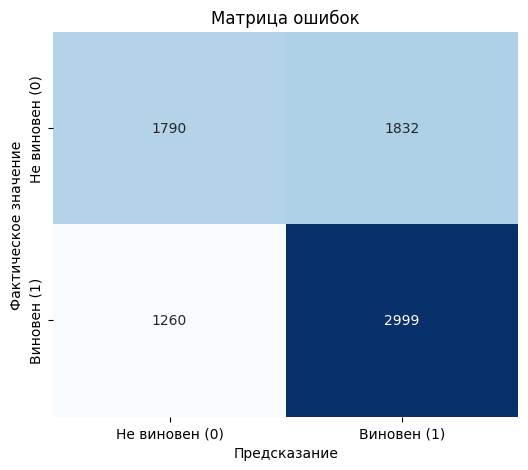

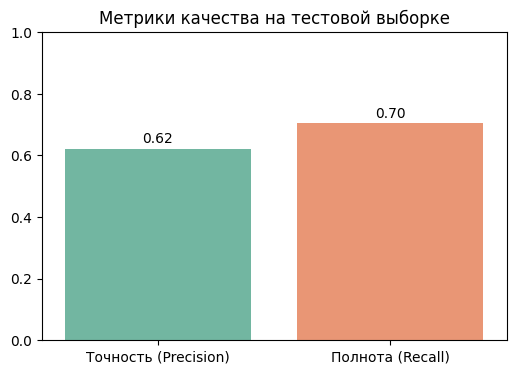

Точность (Precision): 0.621
Полнота (Recall): 0.704


In [ ]:
y_pred = random_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

visual.plot_confusion_matrix(cm)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

visual.plot_metrics(precision, recall)

print(f"Точность (Precision): {precision:.3f}")
print(f"Полнота (Recall): {recall:.3f}")


Модель демонстрирует Precision = 0.621 и Recall = 0.704, что отражает умеренный баланс между точностью и полнотой.
Из матрицы ошибок видно, что система лучше выявляет виновных (2999 из 4259, Recall ≈ 70%), чем невиновных (1790 из 3622, Precision ≈ 62%). Модель склонна «перестраховываться», чаще классифицируя участников как виновных, чем как невиновных.

**Итого:** Модель может использоваться как вспомогательный инструмент при оценке риска, так как модель выявляет значимую часть виновных с приемлемым уровнем ошибок.

Для практического применения можно рассмотреть корректировку порога вероятности. Для дальнейшего повышения качества можно расширить набор признаков.

Оценим важность признаков для лучшей модели. Это поможет интерпретировать результаты модели и подготовить рекомендации для заказчика. Построим график важности признаков с помощью метода SHAP. Предварительно нужно повторить обработку датасета для подачи методу через тот же пайплайн.

In [101]:
best_preprocessor = random_search.best_estimator_.named_steps['preprocessor']


In [102]:
X_train_transformed = pd.DataFrame(
    best_preprocessor.transform(X_train),  
    columns=best_preprocessor.get_feature_names_out()
)

X_test_transformed = pd.DataFrame(
    best_preprocessor.transform(X_test),
    columns=best_preprocessor.get_feature_names_out()
)


In [103]:
display(X_train_transformed.head(2))
display(X_test_transformed.head(2))


,oe__cellphone_in_use,oe__lighting,oe__road_condition,oe__road_surface,oe__vehicle_transmission,oe__vehicle_type,oe__weather,num__distance,num__vehicle_age
0,2.000,2.000,5.000,1.000,2.000,2.000,1.000,-0.398,-0.668
1,0.000,1.000,5.000,1.000,2.000,2.000,1.000,8.889,-0.668


,oe__cellphone_in_use,oe__lighting,oe__road_condition,oe__road_surface,oe__vehicle_transmission,oe__vehicle_type,oe__weather,num__distance,num__vehicle_age
0,0.000,4.000,5.000,1.000,1.000,2.000,2.000,-0.394,-1.617
1,0.000,4.000,5.000,1.000,2.000,2.000,2.000,-0.434,-0.668


In [104]:
explainer = shap.TreeExplainer(random_search.best_estimator_[-1])
shap_values = explainer(X_test_transformed)


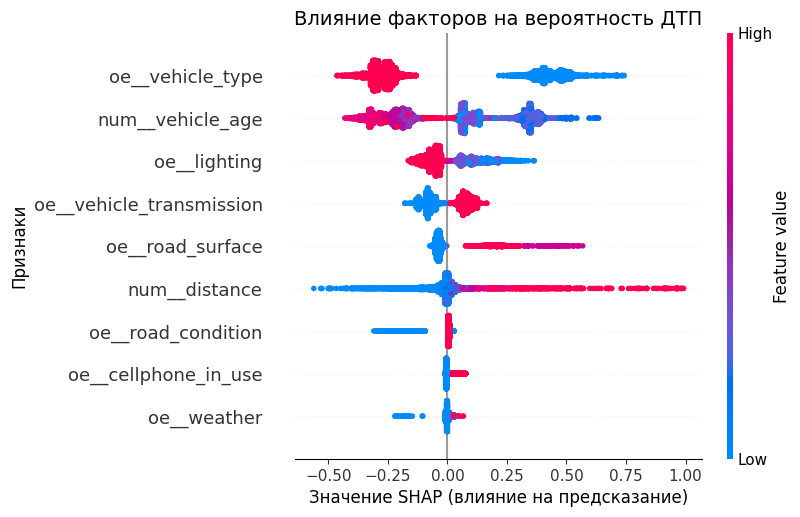

In [105]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="dot", max_display=15, show=False)

plt.title("Влияние факторов на вероятность ДТП", fontsize=14)
plt.ylabel("Признаки", fontsize=12)
plt.xlabel("Значение SHAP (влияние на предсказание)", fontsize=12)
plt.show()


1. **Тип автомобиля (`vehicle_type`)**\
Признак входит в топ по важности: значения способны заметно сдвигать предсказанную вероятность, что указывает на существенную роль типа кузова

2. **Возраст автомобиля (`vehicle_age`)** \
Чем старше транспортное средство, тем выше вероятность того, что водитель окажется виновным. Это может быть связано с техническими неисправностями и сниженной безопасностью старых машин.

3. **Характеристики дороги** \
Большие значения дистанции от главной дороги чаще увеличивают вероятность виновности. 

4. **Дополнительные факторы**\
Использование телефона, погодные условия и состояние дороги (ремонт, нормальное покрытие) оказывают меньшее влияние на итоговое предсказание, однако в комбинации с другими факторами могут повышать риск.

Ключевое влияние на вероятность виновности оказывают **тип и возраст автомобиля**, а также инфраструктурные условия (освещённость, поверхность дороги, удалённость от главной трассы). 

По анализу SHAP наибольший вклад в вероятность виновности даёт признак vehicle_type (тип автомобиля). Чтобы убедиться в характере зависимости, посчитаем долю виновных (at_fault=1) для каждого типа авто и визуализируем её столбчатой диаграммой.

In [124]:
agg = (data
       .groupby('vehicle_type')
       .agg(cases=('at_fault', 'size'),
            faults=('at_fault', 'sum'))
       .reset_index())

agg['fault_rate'] = agg['faults'] / agg['cases'] * 100
print(agg)


  vehicle_type  cases  faults  fault_rate
0        coupe  11897    7766      65.277
1        other      4       2      50.000
2        sedan  19622    9345      47.625


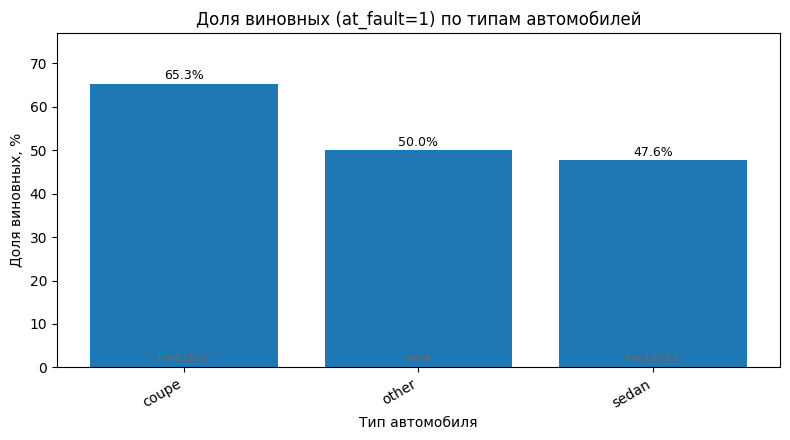

In [126]:
plt.figure(figsize=(8,4.5))
bars = plt.bar(agg['vehicle_type'], agg['fault_rate'])
plt.title('Доля виновных (at_fault=1) по типам автомобилей')
plt.xlabel('Тип автомобиля')
plt.ylabel('Доля виновных, %')
plt.xticks(rotation=30, ha='right')

for b, p, n in zip(bars, agg['fault_rate'], agg['cases']):
    plt.text(b.get_x()+b.get_width()/2, p+1, f'{p:.1f}%', ha='center', fontsize=9)
    plt.text(b.get_x()+b.get_width()/2, 1, f'n={n}', ha='center', va='bottom', fontsize=8, color='dimgray')

plt.ylim(0, max(agg['fault_rate'])*1.18)
plt.tight_layout()
plt.show()


Купе демонстрируют наибольшую долю виновников ДТП — 65,3%. Для категории «other» выборка слишком мала, чтобы делать статистически надёжные выводы (50%, всего 4 случая). Седаны имеют наименьшую долю виновности — 47,6%, но именно этот класс является наиболее массовым (19 622 случая), что и объясняет сильный вклад признака `vehicle_type_sedan` в итоговую модель

Тип кузова известен заранее, поэтому дополнительные датчики для определения этого параметра не требуются. Можно автоматически переводить автомобиль в «профиль повышенной осторожности» для высокорисковых типов авто (доп.проверка давление/износ шин, ошибки и т.п.), тем самым учитывая выявленный фактор. Возможно также, у водителей купе более рискованный тип вождения. В таком случае можно записывать в профиль водителя на сервисе каршеринга характеристики вождения - средняя скорость, ускорения, резкие манёвры. 

<b>Вывод по разделу "Анализ важности факторов ДТП"</b>

1. **Матрица ошибок и метрики качества**: модель демонстрирует сопоставимые значения точности (0.62) и полноты (0.7), что указывает на сбалансированное качество предсказаний и минимальную необходимость в корректировке порога классификации.

2. **Анализ важности факторов (SHAP)**: наибольшее влияние на вероятность ДТП оказывает **тип и возраст автомобиля**, тогда как технические характеристики автомобиля и дорожные условия имеют менее выраженный, но заметный вклад.

3. **Дополнительное исследование фактора трезвости**: наибольший риск связан с автомобилями типа «купе»: у них доля виновных водителей составляет более 65%. Седаны встречаются чаще, но их относительная доля виновных ниже (≈ 48%). Это может объясняться особенностями стиля вождения владельцев купе и более высокой склонностью к агрессивной манере езды.

## Выводы

1. В ходе работы над проектом была разработана модель для предсказания вероятности ДТП:

- В рамках подготовки данных были обработаны пропуски (медиана для числовых признаков, "UNKNOWN" значение для категориальных), удалены аномалии из тренировочной выборки (например, возраст 161 год, экстремальные значения distance), применено кодирование категориальных переменных (OneHotEncoder) и масштабирование числовых признаков (StandardScaler).
- Сравнение четырех моделей (DecisionTreeClassifier, LogisticRegression, LGBMClassifier, DummyClassifier) показало:

**Лучшая модель:** LGBMClassifier с параметрами: `learning_rate`: 0.03816441089227696, `max_depth`: 5, `num_leaves`: 10, `reg_alpha`: 0.010478987566606425, `reg_lambda`: 0.01692681476866447.

В качестве основной метрики была выьрана **ROC-AUC**, т.к. она оценивает качество решений модели в наиболее общем виде, учитывая все возможные пороговые значения. 
**ROC-AUC лучшей модели на тестовой выборке:** 0.653.

2. Построенная модель демонстрирует удовлетворительные значения качества (Precision ≈ 0.62, Recall ≈ 0.7), что говорит о возможности создания системы предварительной оценки риска при выдаче автомобиля. При этом модель лучше выявляет виновных, чем невиновных, что снижает риск недооценки потенциально опасного водителя.

Анализ факторов подтвердил, что наибольшее влияние на вероятность виновности оказывают тип кузова и возраст автомобиля. Автомобили старшего возраста чаще связаны с повышенным риском из-за возможных технических неисправностей, а тип кузова (в частности, различие «седан»/«не седан») заметно влияет на характер предсказаний, что может отражать различия в стилях вождения и сценариях использования. Для снижения риска ДТП можно автоматически переводить автомобиль в «профиль повышенной осторожности» для высокорисковых типов авто (доп.проверка давление/износ шин, ошибки и т.п.), тем самым учитывая выявленный фактор.

3. Для повышения точности прогнозов можно расширить набор данных:
- анализом вождения водителя с сохранением характеристик в профиле водителя (скорость, ускорения, резкие манёвры),
- историей нарушений ПДД,
- частотой использования автомобиля в разных условиях (город, трасса, время суток),
- встроенными датчиками безопасности: алкотестер с биометрической верификацией водителя, камеры для контроля внимания и фиксации использования телефона.

**Итого:** даже на текущем наборе данных возможно построение адекватной системы оценки риска, однако её точность и ценность для бизнеса значительно возрастут при расширении набора признаков, включая технические средства контроля состояния водителя и автомобиля.